In [1]:
# Import all the necessary packages.
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
import sklearn
import matplotlib.pyplot as plt

from sklearn import linear_model
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from statsmodels.formula.api import ols

import warnings  
warnings.filterwarnings('ignore')  

In [5]:
#read the csv file, create a dataframe and sense check the data
reviews = pd.read_csv('turtle_reviews.csv')

print(reviews.dtypes)
print(reviews.info())
print(reviews.describe())

print(reviews.isna())


gender                     object
age                         int64
remuneration (k£)         float64
spending_score (1-100)      int64
loyalty_points              int64
education                  object
language                   object
platform                   object
product                     int64
review                     object
summary                    object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform               

In [7]:
#drop columns language and platform which are meaningless in this context
reviews = reviews.drop(['language', 'platform'], axis = 1)
reviews.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [ ]:
#save the reviews dataframe as a csv file

reviews.to_csv("reviews.csv", index=False)

In [2]:


reviews_copy = pd.read_csv('reviews.csv')
reviews_copy.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [3]:
#Tidy up column names for easier coding

reviews_copy = reviews_copy.rename(columns={'spending_score (1-100)': 'spending_score', 'remuneration (k£)':'remuneration'})

reviews_copy.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [4]:
# Define the dependent variable.
y = reviews_copy['loyalty_points'] 

# Define the independent variable.
X = reviews_copy[['age', 'remuneration','spending_score']]

In [5]:
# Specify the model.
multi = LinearRegression()  

# Fit the model.
multi.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
# Call the predictions for X (array).
multi.predict(X)

array([ -252.52008641,  1238.47746341, -1308.43606252, ...,
        4434.8905332 ,  2066.35892261,  1575.56389984], shape=(2000,))

In [7]:
# Checking the value of R-squared, intercept and coefficients.
print("R-squared: ", multi.score(X, y))
print("Intercept: ", multi.intercept_)
print("Coefficients:")

list(zip(X, multi.coef_))

R-squared:  0.8399114912748796
Intercept:  -2203.059751307901
Coefficients:


[('age', np.float64(11.060658711843349)),
 ('remuneration', np.float64(34.00838549260252)),
 ('spending_score', np.float64(34.183196577633645))]

In [15]:
# Choose your variables.
X2 = reviews_copy[['age', 'remuneration','spending_score']].values
y2 = reviews_copy['loyalty_points'].values.reshape(-1, 1) 

In [16]:
# Split the data into training = 0.7 and testing = 0.3 subsets.
x_train, x_test, y_train, y_test = train_test_split(X2, y2,
                                                    test_size=0.3,
                                                    random_state=42)

In [17]:
# Run linear regression model.
lr = LinearRegression()

# Fit the model on the training data.
lr.fit(x_train, y_train)

# Predict is used for predicting on the x_test.
y_pred = lr.predict(x_test)

# View the output.
y_pred

array([[-4.27284331e+02],
       [ 2.99170289e+03],
       [ 2.59962694e+03],
       [ 1.23130714e+03],
       [ 1.53303118e+03],
       [ 1.78403197e+03],
       [ 4.37649713e+02],
       [ 1.37458806e+03],
       [ 1.36569564e+03],
       [ 3.25384266e+03],
       [ 1.28286928e+03],
       [ 1.65844214e+03],
       [ 1.69708508e+03],
       [ 2.34848804e+03],
       [ 1.28992238e+03],
       [ 1.46361995e+03],
       [ 1.70069241e+03],
       [ 8.17211089e+02],
       [-2.97764878e+01],
       [-9.54815963e+02],
       [ 1.55056071e+03],
       [ 4.88232884e+01],
       [ 1.66586780e+03],
       [ 1.29866549e+03],
       [ 1.41254757e+03],
       [ 1.42832034e+03],
       [ 3.87712853e+03],
       [ 1.62195451e+03],
       [ 1.65586381e+03],
       [ 1.83732493e+03],
       [ 8.88713685e+01],
       [ 6.86808611e+02],
       [ 1.02052107e+03],
       [ 1.71745950e+03],
       [ 1.66391479e+03],
       [ 1.28300128e+03],
       [ 8.92192347e+02],
       [ 2.09089435e+03],
       [ 1.3

In [2]:
#import libraries to do a decision tree analysis

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split 


In [3]:
#import the data from our cleaned csv file
df2 = pd.read_csv('reviews.csv')

In [4]:
#sense check
df2.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2['gender'] = le.fit_transform(df2['gender'])
df2['education'] = le.fit_transform(df2['education'])

df2.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,1,18,12.30,39,210,3,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,1,23,12.30,81,524,3,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,0,22,13.12,6,40,3,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,0,25,13.12,77,562,3,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,0,33,13.94,40,366,3,291,As my review of GF9's previous screens these w...,Money trap


In [22]:
#create the Y depedent and X independent variables

y3 = df2['loyalty_points']
X3 = df2[['age', 'remuneration (k£)', 'spending_score (1-100)','gender','education']]

In [23]:
#split the data for training and test sets

X3_train,X3_test,y3_train,y3_test=train_test_split(X3,y3,random_state=42,test_size=0.3)

In [24]:
#import tree regressor, create variable to hold 
#regressor method and train the bad boy

from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor( random_state=42)
regressor.fit(X3_train,y3_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
# Predict using the training data
y3_train_predicted=regressor.predict(X3_train)

# Predict using the test data
y3_test_predicted=regressor.predict(X3_test)

# Print accuracy values
print(accuracy_score(y3_train,y3_train_predicted)) # prediction is the same as the observation
print(accuracy_score(y3_test,y3_test_predicted)) # prediction on 'unseen data'

1.0
0.71


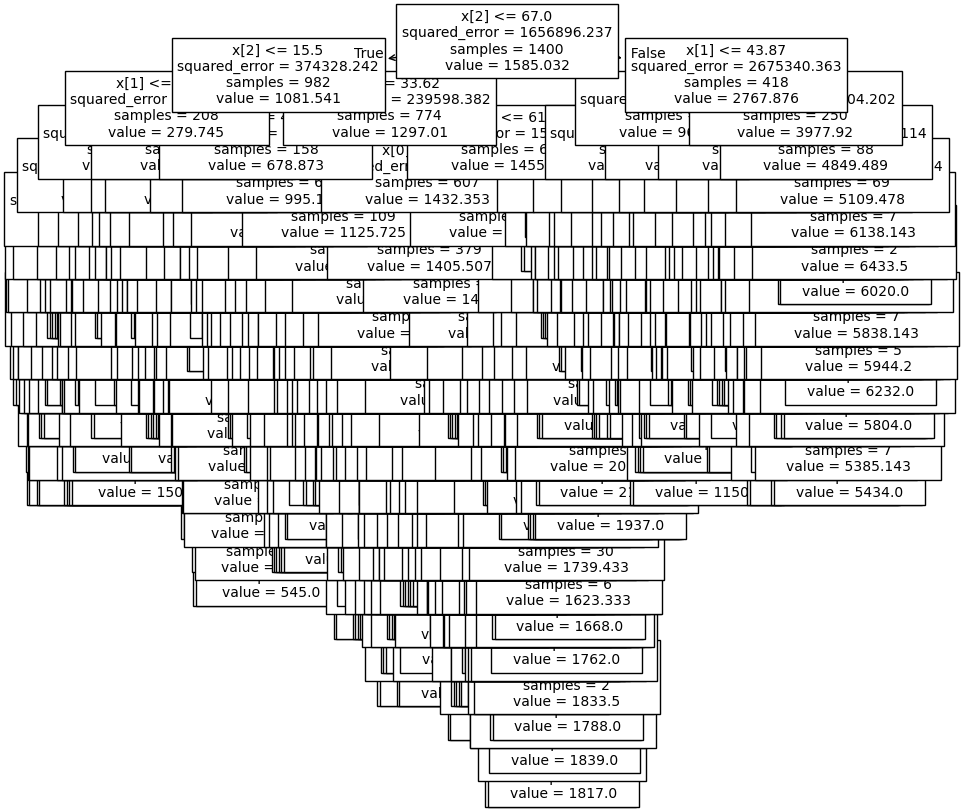

In [17]:
# Plot the tree

# Plot the decision tree to create the visualisation:
fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(regressor, fontsize=10)

# Print the plot with plt.show().
plt.show() 

In [27]:
#compute the prunning path

path = regressor.cost_complexity_pruning_path(X3_train, y3_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(ccp_alphas[:10])

[0.         0.0002381  0.00035714 0.00035714 0.00035714 0.00047619
 0.00059524 0.00059524 0.00059524 0.00095238]


In [29]:
from sklearn.model_selection import cross_val_score

mean_mse = []

for alpha in ccp_alphas:
    regressor = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha
    )

    mse = -cross_val_score(
        regressor,
        X3_train,
        y3_train,
        cv=5,
        scoring='neg_mean_squared_error'
    ).mean()

    mean_mse.append(mse)

best_alpha = ccp_alphas[np.argmin(mean_mse)]
print("Best alpha:", best_alpha)

Best alpha: 0.005510204081656411


In [32]:
#use best alpha score to prune down tree
reg_final_tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=best_alpha
)

reg_final_tree.fit(X3_train, y3_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,np.float64(0....0204081656411)


In [34]:
#test its accuracy
reg_final_tree.score(X3_test, y3_test)

0.9946255142189183

In [35]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X3_train, y3_train)

print(dummy.score(X3_test, y3_test))

-0.0003361326663757769


In [3]:
#let's do it all again for some K Clustering and Decision tree analysis

#import the data from our cleaned csv file
df3 = pd.read_csv('reviews.csv')
df3.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [7]:
df3 = df3[['remuneration (k£)', 'spending_score (1-100)']]
df3.head()

,remuneration (k£),spending_score (1-100)
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40


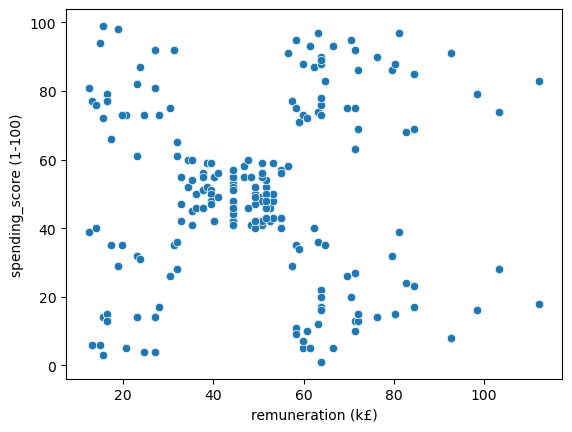

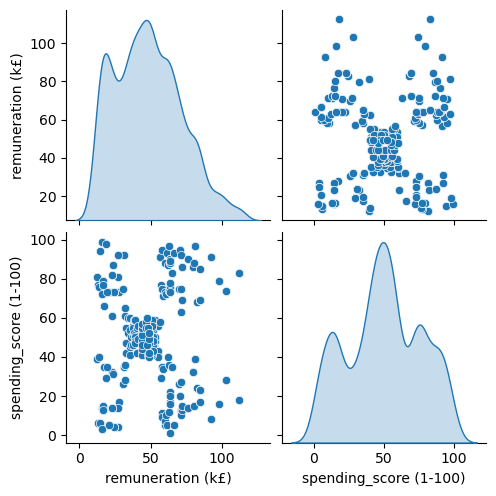

In [9]:
# Import Seaborn and Matplotlib.
from matplotlib import pyplot as plt
import seaborn as sns

# Create a scatterplot with Seaborn.
sns.scatterplot(x='remuneration (k£)',
                y='spending_score (1-100)',
                data=df3)

# Create a pairplot with Seaborn.
x = df3[['remuneration (k£)', 'spending_score (1-100)']]

sns.pairplot(df3,
             vars=x,
             diag_kind= 'kde')

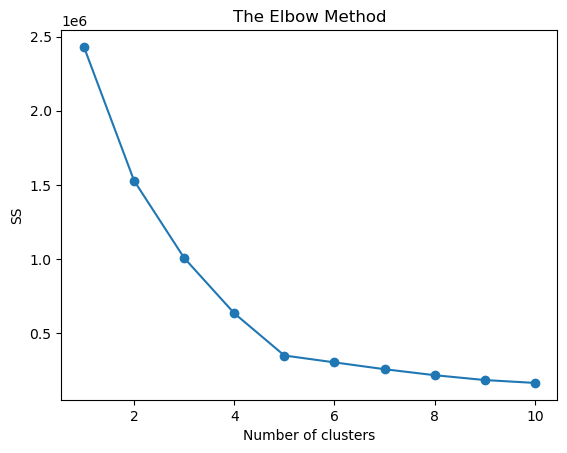

In [10]:
# Import the KMeans class.
from sklearn.cluster import KMeans 

# Elbow chart for us to decide on the number of optimal clusters.
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i,
                    init = 'k-means++', 
                    max_iter = 500,
                    n_init = 10,
                    random_state = 42)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

plt.plot(range(1, 11),
         ss,
         marker='o')

plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SS")

plt.show()

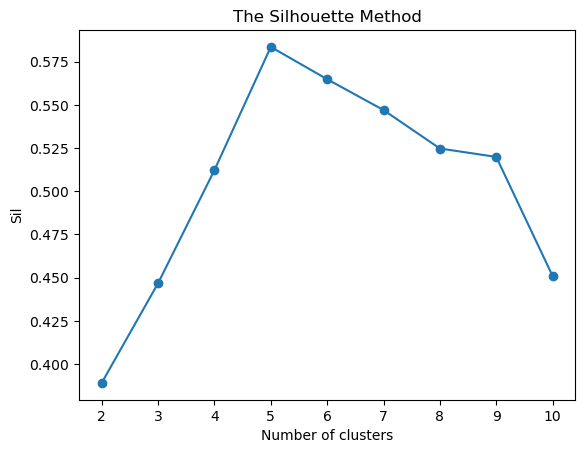

In [11]:
# Import silhouette_score class from sklearn.
from sklearn.metrics import silhouette_score

# Find the range of clusters to be used using silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters = k).fit(x)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(x,
                                labels,
                                metric = 'euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

plt.title("The Silhouette Method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")

plt.show()

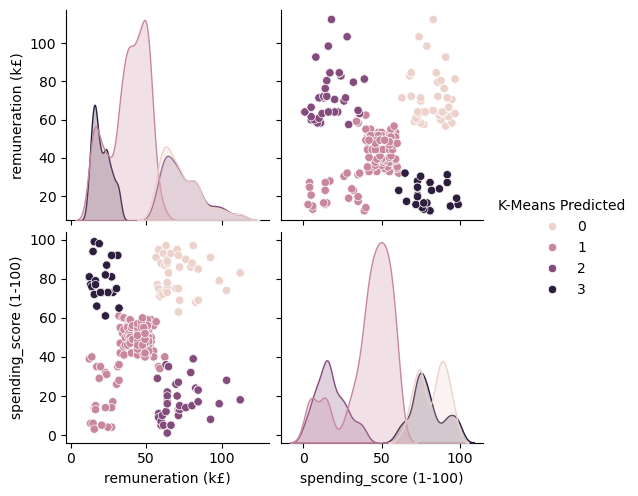

In [12]:
# Use 4 clusters:
kmeans = KMeans(n_clusters = 4,
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(x)

clusters = kmeans.labels_
x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [13]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
1    1045
0     356
2     330
3     269
Name: count, dtype: int64

<Axes: xlabel='remuneration (k£)', ylabel='spending_score (1-100)'>

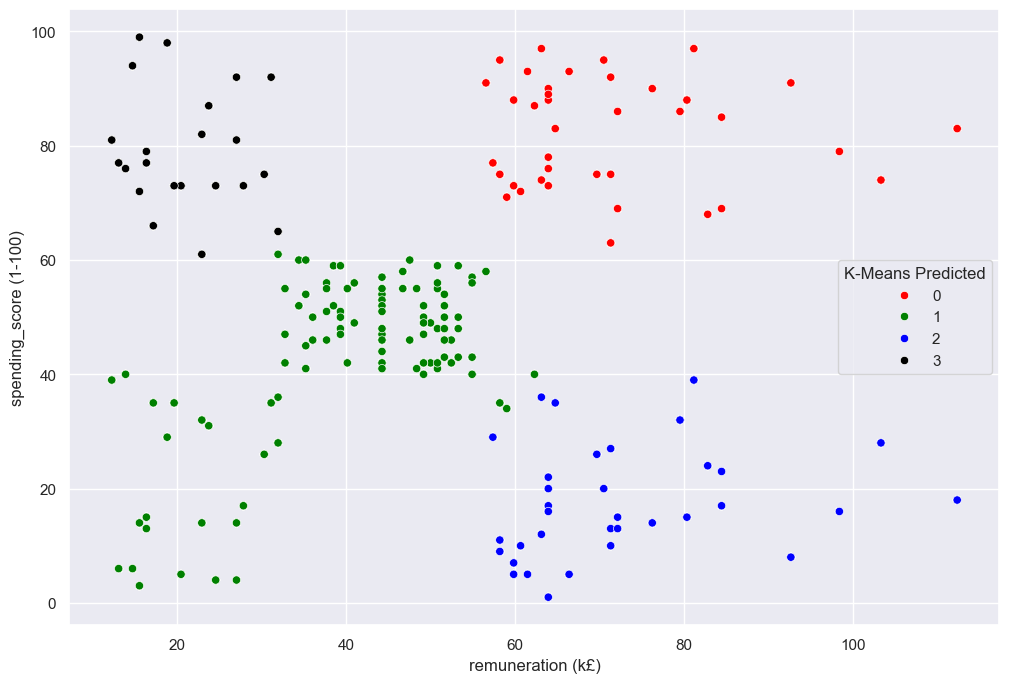

In [14]:
# Visualising the clusters.
# Set plot size.
sns.set(rc = {'figure.figsize':(12, 8)})

sns.scatterplot(x= 'remuneration (k£)',
                y='spending_score (1-100)',
                data=x ,
                hue='K-Means Predicted',
                palette=['red', 'green', 'blue', 'black'])

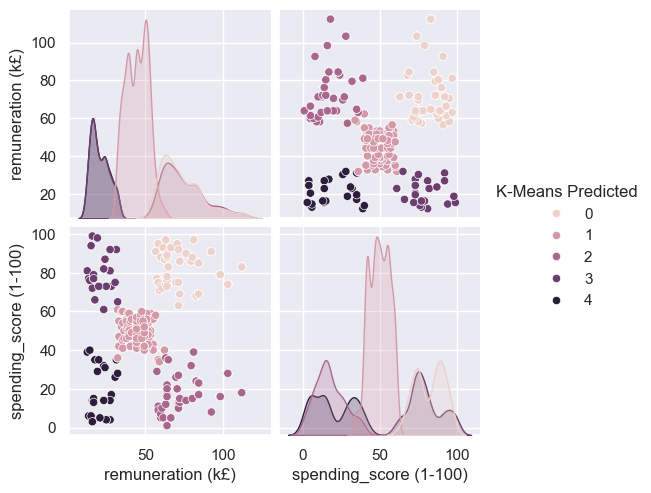

In [15]:
# Use 5 clusters:
kmeans = KMeans(n_clusters = 5,
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(x)

clusters = kmeans.labels_
x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [16]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
1    774
0    356
2    330
4    271
3    269
Name: count, dtype: int64

<Axes: xlabel='remuneration (k£)', ylabel='spending_score (1-100)'>

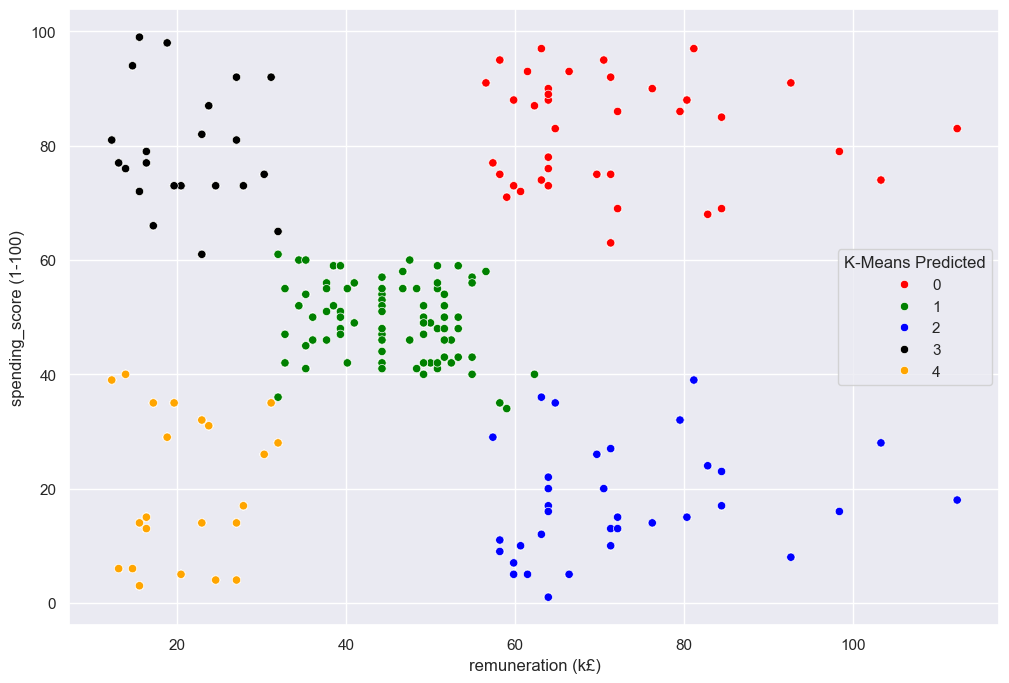

In [17]:
# Visualising the clusters.
# Set plot size.
sns.set(rc = {'figure.figsize':(12, 8)})

sns.scatterplot(x= 'remuneration (k£)',
                y='spending_score (1-100)',
                data=x ,
                hue='K-Means Predicted',
                palette=['red', 'green', 'blue', 'black','orange'])

In [ ]:
#five has better clustering and best sillhoute score
#K means with 5 clusters selected

#you'd want to target the middle renumeration middle spent group in green - middle class as biggest group
#also the orange group who are big renumeration big spend
#the blue group represent the biggest opportunity though as they could become part of the orange group - big dough, big spend